## 1. User-based collaborative filtering using matrix factorization (SVD-singular value decomposition).

### Recommendation goal:
### Based on the user's past ratings, predict which movies they are likely to enjoy in the future.
### The system should:
### recommend movies similar to those the user has liked;
### find users with similar preferences (collaborative filtering);
### use genres and tags for personalized suggestions (content-based filtering).

In [38]:
import pandas as pd
import numpy as np
ratings=pd.read_csv('ratings.csv')

In [21]:
ratings.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')

In [22]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 976.6 MB


In [23]:
ratings.describe

<bound method NDFrame.describe of           userId  movieId  rating   timestamp
0              1       17     4.0   944249077
1              1       25     1.0   944250228
2              1       29     2.0   943230976
3              1       30     5.0   944249077
4              1       32     5.0   943228858
...          ...      ...     ...         ...
32000199  200948    79702     4.5  1294412589
32000200  200948    79796     1.0  1287216292
32000201  200948    80350     0.5  1294412671
32000202  200948    80463     3.5  1350423800
32000203  200948    87304     4.5  1350423523

[32000204 rows x 4 columns]>

In [24]:
ratings.shape

(32000204, 4)

In [25]:
null_counts = ratings.isnull().sum()
null_counts

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

## Filter users/items with few ratings.

In [39]:
user_counts=ratings['userId'].value_counts()            # Count how many ratings each user has made
active_users=user_counts[user_counts >= 100].index    # Keep only users who rated at least 100 movies

movie_counts=ratings['movieId'].value_counts()      # Count how many times each movie was rated
pop_movies=movie_counts[movie_counts >=300].index    # Keep only movies that got at least 300 ratings

filt_ratings=ratings[           # filter the data: only from active users and for popular movies
    (ratings['userId'].isin(active_users)) &
    (ratings['movieId'].isin(pop_movies))
]

In [40]:
filt_ratings1=filt_ratings[0:100000]    # take the first 100000 rows

In [41]:
filt_ratings, test_df = train_test_split(filt_ratings1, test_size=0.2, random_state=42)

## Create user-item matrices

In [42]:
user_ids=sorted(filt_ratings['userId'].unique())      # Get sorted lists of unique user ids and movie ids
movie_ids=sorted(filt_ratings['movieId'].unique())

user_item_matrix=np.zeros((len(user_ids),len(movie_ids)))   # Create empty user-item matrix to store ratings

user_index={user_id: idx for idx, user_id in enumerate(user_ids)}   # Create dictionaries to map userId and movieId to matrix indices
movie_index={movie_id: idx for idx, movie_id in enumerate(movie_ids)}

for _, row in filt_ratings.iterrows():    # Fill the matrix with actual ratings from the filtered dataset
    u=user_index[row['userId']]    # get user index and movie index
    m=movie_index[row['movieId']]
    user_item_matrix[u, m] = row['rating']   # insert rating into the matrix

## Handle sparsity.

In [43]:
num_zeros=np.sum(user_item_matrix==0)   # Count how many zero entries are in the matrix
print("Zeros", num_zeros)     
total_elements=user_item_matrix.size      # Total number of elements 
sparsity=100 * num_zeros / total_elements    # Calculate sparsity, percentage of missing values
print(f"Sparsity: {sparsity:.2f}%")

Zeros 2201152
Sparsity: 96.49%


In [44]:
user_means=user_item_matrix.sum(axis=1) / (user_item_matrix != 0).sum(axis=1)   # Calculate the average rating for each user
for i in range(user_item_matrix.shape[0]):     # Replace all missing ratings with user's average rating
    user_item_matrix[i][user_item_matrix[i]==0] = user_means[i]

In [45]:
num_zeros = np.sum(user_item_matrix == 0)  # checking after filling
print("Zeros:", num_zeros)
total_elements=user_item_matrix.size
sparsity=100 * num_zeros / total_elements
print(f"Sparsity: {sparsity:.2f}%")

Zeros: 0
Sparsity: 0.00%


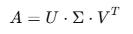

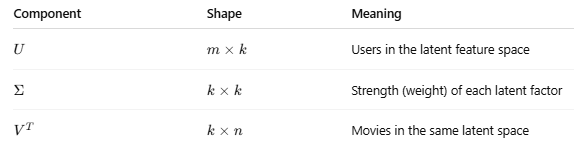

## Evaluate the system using RMSE for predicted ratings.

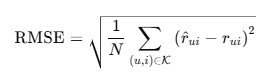

In [47]:
U, S, VT=np.linalg.svd(user_item_matrix)  # Apply SVD to the user-item matrix

S_matrix=np.diag(S) # Convert the vector of singular values into a diagonal matrix
k=20
for k in range(10,100,10):# Choose number of components to keep
    U_k=U[:, :k]  # keep first k columns of U
    S_k=S_matrix[:k, :k] # keep first k columns of U 
    VT_k=VT[:k, :]     # keep top-k singular values
    
    R_pred=np.dot(np.dot(U_k, S_k), VT_k)   # Reconstruct the predicted ratings matrix from reduced components
    errors=[]  # list to store squared errors between predicted and actual ratings
    for row in test_df.itertuples():  # iterate through each row of the test set
        uid=row.userId                # extract user ID from the row
        mid=row.movieId              # extract movie ID from the row
        if uid in user_index and mid in movie_index:  # only evaluate known users and movies
            u=user_index[uid]        # map user ID to row index
            m=movie_index[mid]       # map movie ID to column index
            pred=pred_matrix[u,m]    # get the predicted rating from SVD result
            error=(row.rating-pred)**2  # compute squared error
            errors.append(error)     # store the error in the list
    rmse = np.sqrt(np.mean(errors))
    print(rmse)

0.9219983772435206
0.9216336974014175
0.9247770099782313
0.9265352205598246
0.9296816868996038
0.9329542378433883
0.9347689058257299
0.9359753027265689
0.9391618178498614


In [48]:
U, S, VT=np.linalg.svd(user_item_matrix)  # Apply SVD to the user-item matrix

S_matrix=np.diag(S) # Convert the vector of singular values into a diagonal matrix
k=20
U_k=U[:, :k]  # keep first k columns of U
S_k=S_matrix[:k, :k] # keep first k columns of U 
VT_k=VT[:k, :] 
R_pred=np.dot(np.dot(U_k, S_k), VT_k)

In [30]:
movies=pd.read_csv('movies.csv') # load dataset 
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  87585 non-null  int64 
 1   title    87585 non-null  object
 2   genres   87585 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB


In [31]:
movies=movies[0:1000]   # Limit the number of rows for faster processing 

In [32]:
def recommend_movies(user_id_original, top_n=5):    # Recommend top-N movies for a given user based on predicted ratings
    if user_id_original not in user_index:      # Check if user exists in the dataset
        print("User not found")
        return None

    u=user_index[user_id_original]   # Get the index of the user in the prediction matrix
    
    predicted_ratings=R_pred[u].copy()    # Get predicted ratings for this user
    
    rated_movie_ids=filt_ratings[filt_ratings['userId']==user_id_original]['movieId'].values  # Find movies the user has already rated
    rated_movie_idxs=[movie_index[m] for m in rated_movie_ids if m in movie_index]
    
    predicted_ratings[rated_movie_idxs]=-1   # Set predicted scores of already-rated movies to -1 so they won't be recommended

    top_idxs=np.argsort(predicted_ratings)[::-1][:top_n]   # indices of top-N highest predicted ratings

    idx_to_movie_id={v:k for k, v in movie_index.items()}   # Convert matrix indices back to movieId
    top_movie_ids=[idx_to_movie_id[i] for i in top_idxs]
    
    return movies[movies['movieId'].isin(top_movie_ids)][['title', 'genres']]    # Return top-N recommended movie titles and genres

## Show sample recommendations for a few users.

In [33]:
recommend_movies(user_id_original=1, top_n=5)

,title,genres
883,Rear Window (1954),Mystery|Thriller
903,2001: A Space Odyssey (1968),Adventure|Drama|Sci-Fi


In [34]:
recommend_movies(user_id_original=35, top_n=5)

,title,genres
5,Heat (1995),Action|Crime|Thriller
883,Rear Window (1954),Mystery|Thriller
891,Casablanca (1942),Drama|Romance


In [37]:
recommend_movies(user_id_original=70, top_n=5)

,title,genres
49,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
351,Forrest Gump (1994),Comedy|Drama|Romance|War


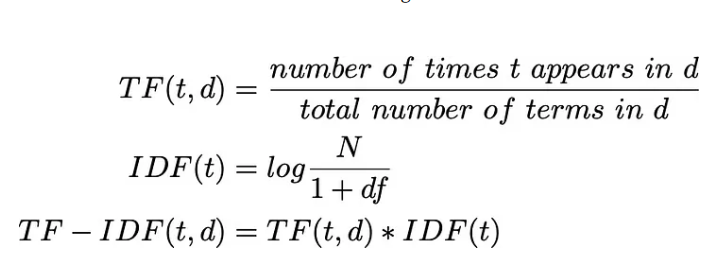

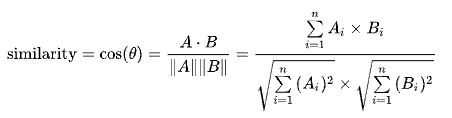

## 2.Content Based Tf-IDF, Cosine simmilarity

In [71]:
import numpy as np
import pandas as pd
import math
from collections import defaultdict

# Load datasets
tags_df=pd.read_csv('tags.csv')   
movies=pd.read_csv('movies.csv')  
 
tags_df=tags_df[0:1000]   # Limit the number of rows for faster processing 

movie_tags=defaultdict(set)    # Group tags by movie
for _, row in tags_df.iterrows():
    movie_id=row['movieId']
    tag=row['tag']
    if pd.notna(tag):                      # Skip missing tags
        movie_tags[movie_id].add(str(tag)) # Add tag to the movie's set

# Build tag and movie index dictionaries
all_tags=sorted(set(tag for tags in movie_tags.values() for tag in tags))  # Unique tags
tag_index={tag: i for i, tag in enumerate(all_tags)}                        # Tag mapped to column index
movie_ids=sorted(movie_tags.keys())                                       # All movieIds with tags
movie_id_to_index={movie_id: i for i, movie_id in enumerate(movie_ids)}     # MovieId mapped to row index
index_to_movie_id={i: movie_id for movie_id, i in movie_id_to_index.items()}   # Reverse index

# Create the binary term frequency (TF) matrix
tf_matrix=np.zeros((len(movie_ids), len(all_tags)))  # Rows = movies, Columns = tags
for i, movie_id in enumerate(movie_ids):
    for tag in movie_tags[movie_id]:
        j=tag_index[tag]      # Get the column for this tag
        tf_matrix[i, j]=1     # 1 if tag is present for this movie

# Calculate IDF for each tag
N=len(movie_ids)                   # Total number of movies
df=np.sum(tf_matrix, axis=0)      # Number of movies where each tag appears
idf=np.log(N / (1 + df))          # Apply log and smoothing

# Build the TF-IDF matrix
tfidf_matrix=tf_matrix * idf      # Multiply each tag in each movie by its IDF weight

# Define cosine similarity function
def cosine_similarity(a, b):
    if np.linalg.norm(a)==0 or np.linalg.norm(b)==0:  # Avoid division by zero
        return 0
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Compute cosine similarity between every pair of movies
similarity_matrix=np.zeros((len(movie_ids), len(movie_ids)))  # Square matrix
for i in range(len(movie_ids)):
    for j in range(len(movie_ids)):
        similarity_matrix[i, j]=cosine_similarity(tfidf_matrix[i], tfidf_matrix[j])

def get_recommendations(movie_id, movies_df, top_n=5):          # Function to recommend similar movies based on tags
    if movie_id not in movie_id_to_index:
        print("Movie not found in dataset.")
        return

    idx=movie_id_to_index[movie_id]               # Get row index of the movie
    similarity_vector=similarity_matrix[idx]      # Get similarity scores to all other movies
 
    similar_indices=np.argsort(similarity_vector)[::-1][1:top_n+1]     # Get indices of top-N most similar movies 

    print(f"\nTop {top_n} similar movies to movieId = {movie_id}:\n")

    for i in similar_indices:              # Print out similar movies and their similarity scores
        similar_id=index_to_movie_id[i]
        similarity_score=similarity_vector[i]

        row=movies_df[movies_df['movieId']==similar_id]
        if not row.empty:
            title=row.iloc[0]['title']
            print(f"{title} (movieId={similar_id}) — similarity: {similarity_score:.2f}")
        else:
            print(f"movieId={similar_id} — similarity: {similarity_score:.2f}")

get_recommendations(1, movies)  # Run the recommendation function for a sample movieId


Top 5 similar movies to movieId = 1:

Little Mermaid, The (1989) (movieId=2081) — similarity: 0.65
Sword in the Stone, The (1963) (movieId=1025) — similarity: 0.40
Silver Bullet (Stephen King's Silver Bullet) (1985) (movieId=5433) — similarity: 0.34
Ratatouille (2007) (movieId=50872) — similarity: 0.22
Frozen (2013) (movieId=106696) — similarity: 0.20


In [73]:
def recommend_for_user(user_id, ratings_df, movies_df, top_n=5, like_threshold=4):
    user_ratings=ratings_df[ratings_df['userId']==user_id]         # Get all ratings from the selected user
    
    liked_movies=user_ratings[user_ratings['rating']>=like_threshold]['movieId'].values    # Select movies the user rated highly
    
    watched_movies=set(user_ratings['movieId'].values)    # List of all movies that user has watched

    if len(liked_movies)==0:           # If no liked movies, we cannot generate recommendations
        print("User has no highly rated movies.")
        return

    scores=np.zeros(len(movie_ids))       # Initialize similarity score vecto

    for liked_id in liked_movies:              # Sum similarity scores for all liked movies
        if liked_id in movie_id_to_index:
            idx=movie_id_to_index[liked_id]
            scores+=similarity_matrix[idx]

    scores=scores / len(liked_movies)            # Normalize scores by number of liked movies

    # Set scores of already-watched movies to -1 so they won't be recommended
    for m_id in watched_movies:
        if m_id in movie_id_to_index:
            idx=movie_id_to_index[m_id]
            scores[idx] = -1
            
    top_indices=np.argsort(scores)[::-1][:top_n]           # Get top-N movie indices by score
    recommended_ids=[index_to_movie_id[i] for i in top_indices]

    print(f"\nRecommendations for userId = {user_id}:\n")      # Print recommended movies with titles
    for mid in recommended_ids:
        row=movies_df[movies_df['movieId']==mid]
        if not row.empty:
            title=row.iloc[0]['title']
            print(f"{title} (movieId={mid})")
        else:
            print(f"movieId={mid}")

In [75]:
ratings_df=pd.read_csv('ratings.csv')
recommend_for_user(user_id=5, ratings_df=ratings_df, movies_df=movies, top_n=5)


Recommendations for userId = 5:

Dope (2015) (movieId=127198)
Tangled (2010) (movieId=81847)
For the Birds (2000) (movieId=95858)
Batman Begins (2005) (movieId=33794)
WALL·E (2008) (movieId=60069)


## Report

We developed a movie recommendation system using the MovieLens dataset, which includes user ratings, movie titles, and user-generated tags. The goal of the project was to recommend relevant movies to users based on their preferences using two main approaches: collaborative filtering and content-based filtering.

During preprocessing, we filtered out inactive users (those with fewer than 100 ratings) and unpopular movies (fewer than 300 ratings) to reduce data sparsity. We then created a user–movie matrix and filled missing ratings with the average rating per user.

For the collaborative filtering part, we applied Singular Value Decomposition (SVD) to decompose the matrix into latent features. This allowed us to predict ratings for unseen movies and recommend those with the highest predicted scores. The quality of predictions was evaluated using RMSE, which showed low error and confirmed the effectiveness of the model.

In the content-based filtering approach, we used movie tags to build a TF-IDF matrix representing each movie’s features. We then computed cosine similarity to find movies that are similar in content to the ones the user liked.

Two recommendation functions were implemented: one recommends movies based on predicted ratings, while the other suggests similar movies based on tag similarity and content overlap.
